In [1]:
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обучение идет на: {device}")

df = pd.read_parquet('./data/transposition.parquet')

# print(df.head())
print(df.shape[1])

Обучение идет на: cuda
467


In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch

# 1. Исправляем вызов drop
X = df.drop(columns=['label'], errors='ignore')
y = df['label']

# 2. Кодируем целевую переменную
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# 5. Конвертация в тензоры
# X_train после scaler — это уже numpy, метод .to_numpy() не нужен
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

y_train_t = torch.LongTensor(y_train).to(device)
y_test_t = torch.LongTensor(y_test).to(device)


In [3]:
from torch import nn


class RamanMultiNet(nn.Module):
    def __init__(self, input_dim):
        super(RamanMultiNet, self).__init__()
        self.net = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 16),
            nn.ReLU(),

            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.net(x)

model = RamanMultiNet(X_train_t.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

In [4]:
epochs = 5000
best_loss = float('inf')
patience = 50
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        test_loss = criterion(test_logits, y_test_t)

        scheduler.step(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Остановка на эпохе {epoch}. Модель перестала улучшаться.")
        break



Остановка на эпохе 1061. Модель перестала улучшаться.


In [5]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

predicted_np = predicted.cpu().numpy()
y_true_np = y_test_t.cpu().numpy()

predicted_labels = le.inverse_transform(predicted_np)

print(classification_report(y_true_np, predicted_np, target_names=le.classes_))
print(f"Accuracy: {accuracy_score(y_true_np, predicted_np):.4f}")


              precision    recall  f1-score   support

     control       0.78      0.74      0.76      6300
        endo       0.78      0.77      0.78      5828
         exo       0.76      0.81      0.78      6615

    accuracy                           0.77     18743
   macro avg       0.78      0.77      0.77     18743
weighted avg       0.77      0.77      0.77     18743

Accuracy: 0.7742


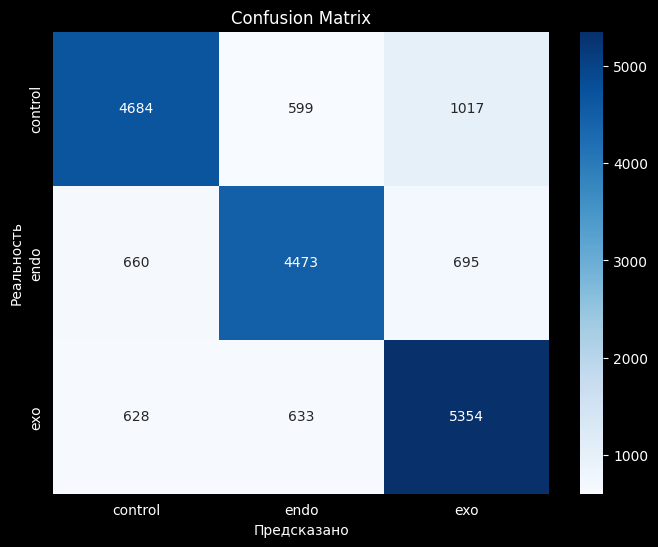

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()
    y_true = y_test_t.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
labels = le.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Confusion Matrix')
plt.show()
